In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
import seaborn as sn

In [ ]:
data = pd.read_csv('/content/datingTestSet.csv', header=None)
data = data[0].str.split('\t', expand=True)
print(data.shape)
data.head()

(1000, 4)


,0,1,2,3
0,40920,8.326976,0.953952,largeDoses
1,14488,7.153469,1.673904,smallDoses
2,26052,1.441871,0.805124,didntLike
3,75136,13.147394,0.428964,didntLike
4,38344,1.669788,0.134296,didntLike


In [ ]:
data.isnull().sum()

,0
0,0
1,0
2,0
3,0


In [ ]:
x=data.iloc[:, :-1].values
y=data.iloc[:, -1].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
results=[]
for i in [1,2,3,4,5]:
  model = KNeighborsClassifier(n_neighbors=i,metric='minkowski', p=2)
  model.fit(x_train, y_train)
  y_pred=model.predict (x_test)
  Accuracy_score=metrics.accuracy_score(y_test, y_pred)
  results.append (Accuracy_score)
print('KNN [ minkowski ]')
print('for n neighbor=5 : ')
conf_mat=metrics.confusion_matrix(y_test, y_pred)
print('\n Confusion Matrix: ', conf_mat)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ',
int (Accuracy_score*100),'%')
print('\n',classification_report(y_pred, y_test))
print(results)

KNN [ minkowski ]
for n neighbor=5 : 

 Confusion Matrix:  [[94  2  1]
 [ 4 94  3]
 [ 1  4 97]]
Accuracy Score :  0.95
Accuracy in Percentage :  95 %

               precision    recall  f1-score   support

   didntLike       0.97      0.95      0.96        99
  largeDoses       0.93      0.94      0.94       100
  smallDoses       0.95      0.96      0.96       101

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

[0.93, 0.9233333333333333, 0.9366666666666666, 0.9466666666666667, 0.95]


[Text(0.5, 1.0, 'KNN [minkowski, neighbor=5 ]')]

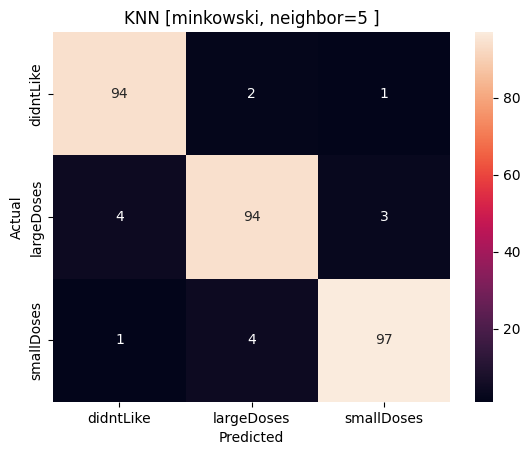

In [ ]:
conf_mat=pd.crosstab(y_test, y_pred, rownames=['Actual'],colnames=['Predicted'])
sn.heatmap(conf_mat, annot=True).set(title='KNN [minkowski, neighbor=5 ]')

In [ ]:
models = pd.DataFrame ( {
'n_neighbors': ['1', '2','3','4','5'],
'Accuracy Score':
[results[0],results[1], results[2],results[3],results[4]]})
models.sort_values (by='Accuracy Score')
print (models.to_string(index=False))

n_neighbors  Accuracy Score
          1        0.930000
          2        0.923333
          3        0.936667
          4        0.946667
          5        0.950000
